# XCT Defect Segmentation Demo

Demonstrates the **3D XCT defect-segmentation and analysis** pipeline for
laser powder bed fusion (LPBF) parts on a **synthetic CT volume**, so it runs
without the (large) real XCT stacks.

To use real data, replace the synthetic block with:
`xctdefect.io.load_tiff_stack("data/sample5", crop=(60, 420, 150, 500))`.

Pipeline:
1. **Preprocess** - K-means defect/solid separation
2. **Segment** - 3D Voronoi-Otsu labeling
3. **Features** - per-defect volume, ESD, bounding box, porosity
4. **Cluster** - DBSCAN -> typical defects vs. outliers
5. **Point cloud** - export & projections

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import xctdefect

## 1. Build a synthetic XCT volume

A solid block (bright) containing many spherical pores (the defects), with additive noise. Defects are made bright so the labeling can pick them up.

volume: (80, 80, 60)


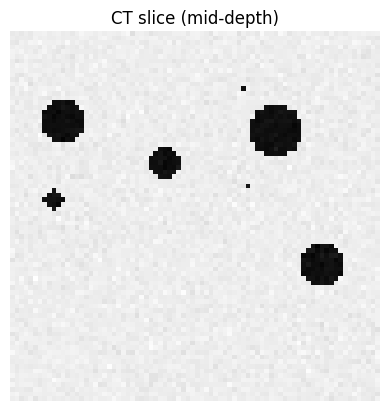

In [2]:
rng = np.random.default_rng(0)
H, W, D = 80, 80, 60
solid = np.full((H, W, D), 200, dtype=np.int16)
zz, yy, xx = np.mgrid[0:H, 0:W, 0:D]

# Two size populations so DBSCAN has structure to find.
for _ in range(60):
    cy, cx, cz = rng.integers(6, H-6), rng.integers(6, W-6), rng.integers(5, D-5)
    r = rng.choice([2, 3, 6])          # mostly small pores, a few large
    pore = ((yy-cy)**2 + (xx-cx)**2 + (zz-cz)**2) <= r**2
    solid[pore] = 30

solid = np.clip(solid + rng.normal(0, 4, solid.shape).astype(np.int16), 0, 255).astype(np.uint8)
defect_bright = (255 - solid).astype(np.uint8)   # invert: defects bright
print("volume:", defect_bright.shape)

mid = D // 2
plt.imshow(solid[:, :, mid], cmap="gray"); plt.title("CT slice (mid-depth)"); plt.axis("off"); plt.show()

## 2-3. Segment & extract features

Voronoi-Otsu labeling assigns each pore a unique integer label; then we tabulate per-defect geometry and compute global porosity.

In [3]:
labels = xctdefect.segmentation.voronoi_otsu_labeling(
    defect_bright, spot_sigma=2.0, outline_sigma=2.0)
print("defects labeled:", int(labels.max()))

table = xctdefect.features.defect_table(labels, voxel_size=2.5)
porosity = xctdefect.features.global_porosity(labels)
print("global porosity: %.4f" % porosity)
table.head()

defects labeled: 28
global porosity: 0.0665


,label,volume,esd,bbox_width,bbox_height,bbox_depth,centroid_0,centroid_1,centroid_2,aspect_ratio
0,1,19484.375,0.033386,35.0,35.0,30.0,42.838011,39.939054,47.943063,0.857143
1,2,19343.750,0.033305,32.5,35.0,30.0,53.046850,39.843296,47.043619,0.857143
2,3,19015.625,0.033116,32.5,32.5,35.0,49.971241,66.935908,25.952342,0.928571
3,4,19156.250,0.033197,40.0,32.5,32.5,42.033442,65.999184,18.769984,0.812500
4,5,19187.500,0.033215,30.0,32.5,32.5,51.000000,56.000000,54.037459,0.923077


## 4. Pore-size distribution (ESD)

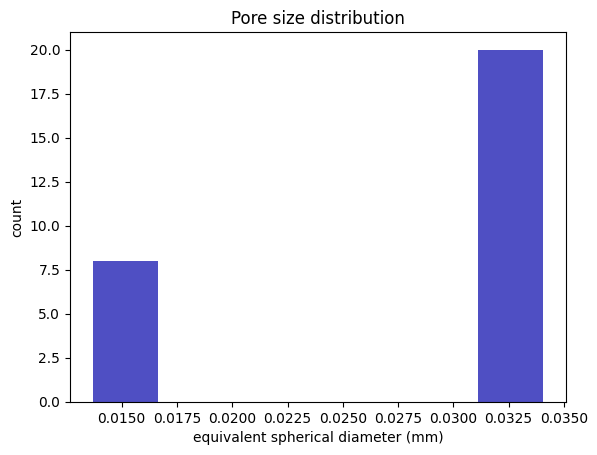

In [4]:
plt.hist(table["esd"], bins="auto", color="#0504aa", alpha=0.7, rwidth=0.85)
plt.xlabel("equivalent spherical diameter (mm)")
plt.ylabel("count"); plt.title("Pore size distribution"); plt.show()

## 5. DBSCAN clustering: typical defects vs. outliers

Defects are clustered in the sorted bounding-box feature space `[max, mid, min]`. The k-distance plot guides the choice of `eps`.

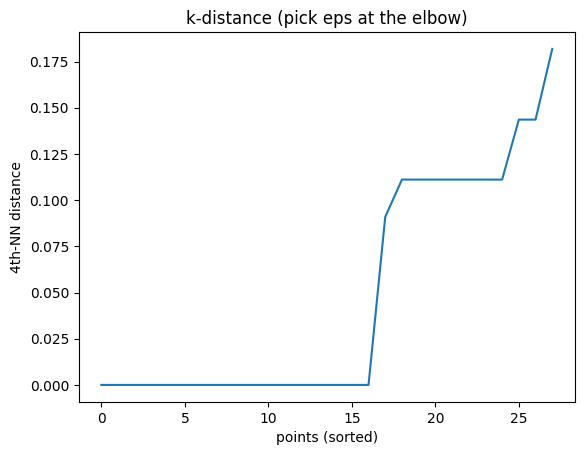

{'counts': {np.int64(0): 20, np.int64(-1): 1, np.int64(1): 7}, 'n_clusters': 2, 'n_outliers': 1}
typical (benchmark) defect dims: {'width': 27.962962962962962, 'height': 28.055555555555557, 'depth': 27.77777777777778}


In [5]:
feats = xctdefect.clustering.sorted_dimension_features(table)

kd = xctdefect.clustering.kdistance(feats, k=4)
plt.plot(kd); plt.xlabel("points (sorted)"); plt.ylabel("4th-NN distance")
plt.title("k-distance (pick eps at the elbow)"); plt.show()

cluster_labels, summary = xctdefect.clustering.dbscan_cluster(feats, eps=0.12, min_samples=4)
print(summary)

benchmark, typical = xctdefect.clustering.typical_defect(table, cluster_labels)
print("typical (benchmark) defect dims:", benchmark)

## 6. 3D defect point cloud

Extract the voxels of all defects and scatter them, colored by label.

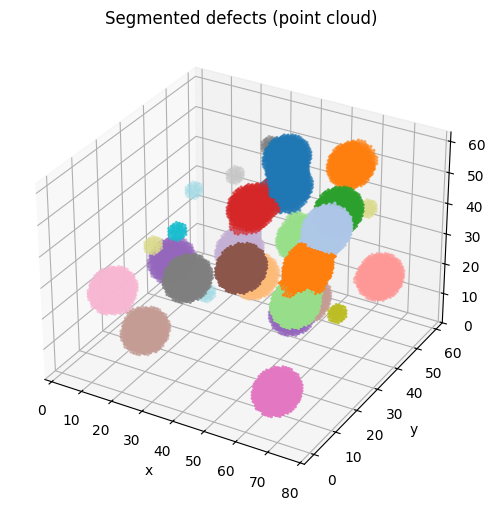

In [6]:
pc = xctdefect.pointcloud.all_defects_point_cloud(labels)
ax = plt.figure(figsize=(7, 6)).add_subplot(projection="3d")
ax.scatter(pc["x"], pc["y"], pc["z"], c=pc["label"], s=2, cmap="tab20")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Segmented defects (point cloud)"); plt.show()

## 7. One-line end-to-end

In [7]:
out = xctdefect.run_pipeline(
    defect_bright, voxel_size=2.5, denoise=False,
    spot_sigma=2.0, outline_sigma=2.0, eps=0.12, min_samples=4)
print("defects:", int(out["labels"].max()))
print("porosity: %.4f" % out["porosity"])
print("clusters:", out["cluster_summary"]["n_clusters"],
      "| outliers:", out["cluster_summary"]["n_outliers"])

defects: 28
porosity: 0.0665
clusters: 2 | outliers: 1
